In [367]:
# import all packages

import pandas as pd
import numpy as np
from datetime import timedelta, datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [368]:
#for creating lags
def lag_window(df, colname,  lag = 1):
    for i in range(lag):
        df[f'lag{i+1}'] = df[colname].shift(i+1)
    df = df.dropna()    
    return df

def lag(df, colname,  lag = 1):
    df[f'lag{lag}'] = df[colname].shift(lag)
    df = df.dropna()
    return df

    
# fix random seed for reproducibility

np.random.seed(7)
# load the dataset
#The ‘daily power usage' dataset summarizes the monthly total number of international passengers in thousands on for an airline from 1949 to 1960.
lookback = 1
df = pd.read_csv('power_usage.csv', engine='python')
df = df.set_index('Index')
#focus on the last two months
df.sort_index(inplace=True)
df = df['2010-11-01 00:00:00':]
df = lag(df, 'Global_active_power', lookback)
df

,Global_active_power,lag1
Index,,
2010-11-01 01:00:00,0.301833,0.311133
2010-11-01 02:00:00,0.296067,0.301833
2010-11-01 03:00:00,0.674767,0.296067
2010-11-01 04:00:00,0.719700,0.674767
2010-11-01 05:00:00,0.310167,0.719700
...,...,...
2010-12-11 19:00:00,2.391967,2.280867
2010-12-11 20:00:00,1.753333,2.391967
2010-12-11 21:00:00,1.114900,1.753333


In [369]:
test_size = 0.3
split = (1//(test_size))-1
split

2.0

In [370]:
test_size = 0.3
split = int((1//(test_size))-1)
X = df.drop(columns =['Global_active_power'])
y = df['Global_active_power']
X_train = X[:int(X.shape[0]*0.7)]
X_test = X[int(X.shape[0]*0.7):]
y_train = y[:int(X.shape[0]*0.7)]
y_test = y[int(X.shape[0]*0.7):]

In [371]:
tscv = TimeSeriesSplit(n_splits=split)
params1 = { 'max_depth': [3,6,10],
           'learning_rate': [0.01, 0.05, 0.1],
           'n_estimators': [100, 500, 1000],
           'colsample_bytree': [0.3, 0.7]}
xgbr = xgb.XGBRegressor(seed = 20)
clf1 = GridSearchCV(estimator=xgbr, 
                   param_grid=params1,
                   scoring='neg_mean_squared_error', 
                   cv=tscv, 
                   verbose=1)
clf1.fit(X_train, y_train)
print("Best parameters:", clf1.best_params_)
print("Lowest RMSE: ", (-clf1.best_score_)**(1/2.0))

Fitting 2 folds for each of 54 candidates, totalling 108 fits
[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[11:49:09] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:10] WARNING: src/objective/regression_obj.cu:152: reg:linear is n

[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[11:49:17] WARNING: src/objective/regression_obj.cu:152: reg:linear is n

[Parallel(n_jobs=1)]: Done 108 out of 108 | elapsed:   10.6s finished


In [381]:
from sklearn.dummy import DummyRegressor
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
DummyRegressor()
dummy_regr.predict(X_test)
print(dummy_regr.score(X_test, y_test))
s = mean_squared_error(y_test, dummy_regr.predict(X_test), squared = False)

abs((-clf1.best_score_)**(1/2.0)-s)/s


-0.009399773842184045


0.10369643391555848

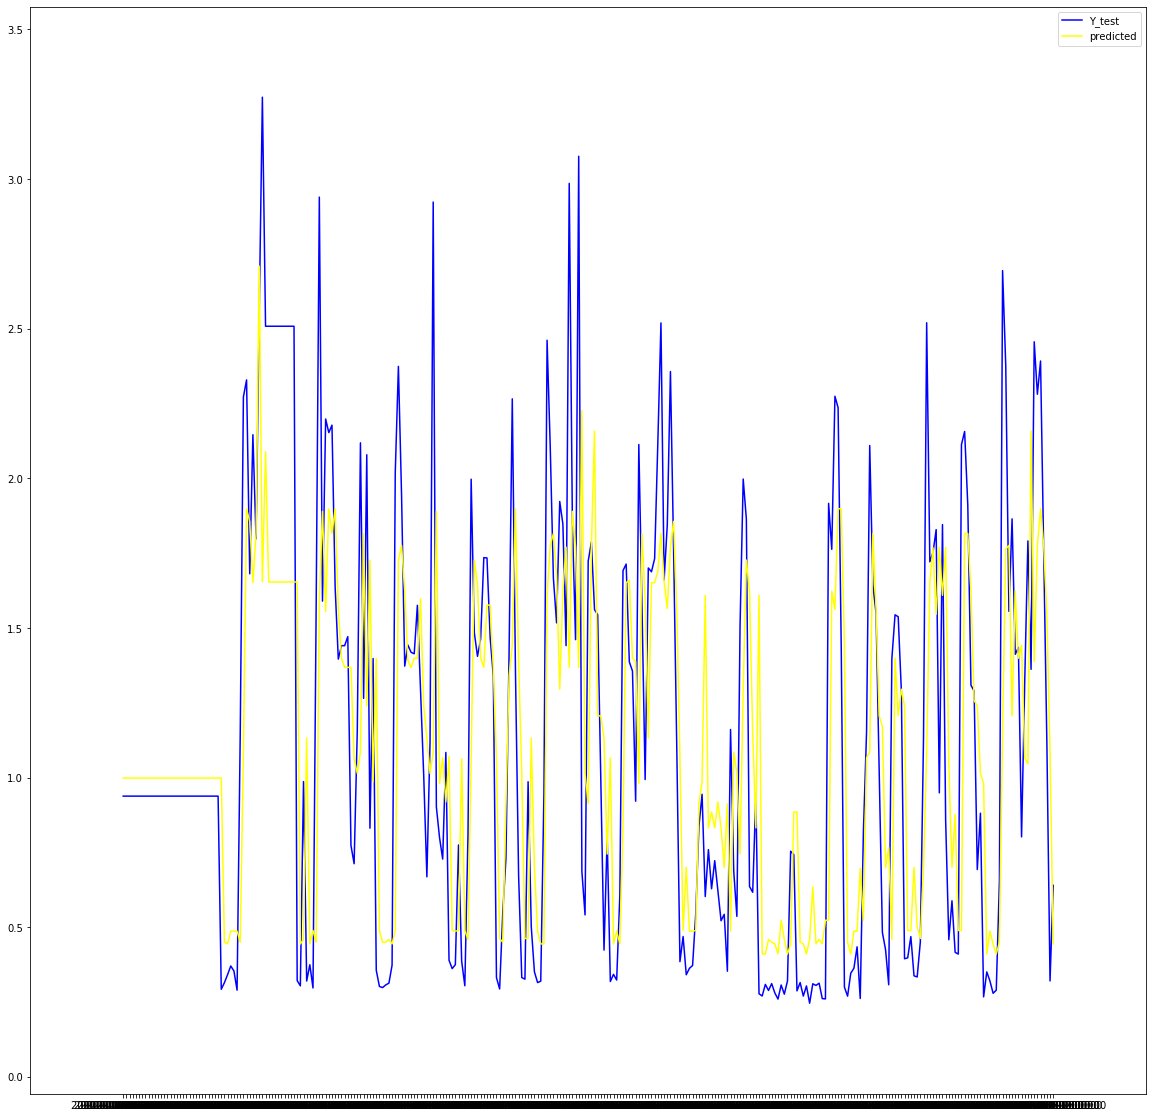

In [366]:
# make predictions
trainPredict = clf1.predict(X_train)
testPredict = clf1.predict(X_test)

# plot baseline and predictions
split_index = len(trainPredict)
test_len = len(testPredict)
Y_train_df = pd.DataFrame(trainPredict, index = y_train.index)
#index = np.arange(split_index-1, split_index+test_len-1)
Y_test_df = pd.DataFrame(y_test)
#Y_test_df = Y_test_df.set_index('Index')
pred = pd.DataFrame(testPredict, index = y_test.index)

plt.rcParams['figure.figsize'] = (20, 20)
#plt.plot(Y_train_df, label='Y_train', )
plt.plot(Y_test_df, label='Y_test', color = 'blue')
plt.plot(pred, label ='predicted', color = 'yellow')
plt.margins(0.1) 
plt.legend()
plt.show()

In [355]:
Y_test_df = pd.DataFrame(y_test)
pred = pd.DataFrame(testPredict, index = y_test.index)
pred

,0
Index,
2010-11-23 09:00:00,1.759840
2010-11-23 10:00:00,1.388001
2010-11-23 11:00:00,1.377997
2010-11-23 12:00:00,1.759840
2010-11-23 13:00:00,1.126730
...,...
2010-12-11 19:00:00,1.837822
2010-12-11 20:00:00,1.782806
2010-12-11 21:00:00,1.759840


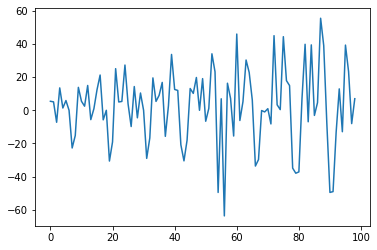

In [214]:
one_diff_trainPredict = np.diff(trainPredict)
Y_train_diff_df = pd.DataFrame(one_diff_trainPredict, index = np.arange(0,split_index-1))
plt.plot(Y_train_diff_df,)
plt.show()


In [215]:
params2 = {'max_depth': [3, 5, 6, 10, 15, 20],
           'learning_rate': [0.01, 0.1, 0.2, 0.3],
           'subsample': np.arange(0.5,1.0,0.1),
           'colsample_bytree': np.arange(0.4, 1.0, 0.1),
           'colsample_bylevel': np.arange(0.4, 1.0, 0.1),
           'n_estimators': [100, 500, 1000]}
clf2 = RandomizedSearchCV(estimator=xgbr,
                         param_distributions=params2,
                         scoring='neg_mean_squared_error',
                         n_iter=25,
                         verbose=1)
clf2.fit(X_train, y_train)
print("Best parameters:", clf2.best_params_)
print("Lowest RMSE: ", (-clf2.best_score_)**(1/2.0))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:48] WARNING: src/objective/regression_obj.cu:152: reg:linear is n

[14:32:51] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:51] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:51] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[14:32:52] WARNING: src/objective/regression_obj.cu:152: reg:linear is n

[Parallel(n_jobs=1)]: Done 125 out of 125 | elapsed:    6.2s finished


In [219]:
clf2.predict(X_test)

#make predictions
trainPredict = clf2.predict(X_train)
testPredict = clf2.predict(X_test)

# plot baseline and predictions
split_index = len(trainPredict)
test_len = len(testPredict)
Y_train_df = pd.DataFrame(trainPredict, index = np.arange(0,split_index))
Y_test_df = pd.DataFrame(Y_test, index = np.arange(split_index,split_index+test_len))
pred = pd.DataFrame(testPredict, index = np.arange(split_index,split_index+test_len))
plt.plot(Y_train_df, label='Y_train')
plt.plot(Y_test_df, label='Y_test')
plt.plot(pred, label ='predicted')
plt.legend()
plt.show()


ValueError: Shape of passed values is (44, 1), indices imply (437, 1)

In [ ]:
np.random.seed(7)
# load the dataset
lookback = 1
df = pd.read_csv('airline-passengers.csv', usecols=[1], engine='python')
df = lag(df, 'Passengers', lookback)
df

In [ ]:
diff_df = df.apply(np.diff)
diff_df

In [ ]:

X = diff_df.drop(columns =['Passengers'])
y = diff_df['Passengers']
diff_X_train = X[:int(X.shape[0]*0.7)]
diff_X_test = X[int(X.shape[0]*0.7):]
diff_y_train = y[:int(X.shape[0]*0.7)]
diff_y_test = y[int(X.shape[0]*0.7):]

In [ ]:
test_size = 0.3
split = int((1//(test_size))-1)
tscvdiff = TimeSeriesSplit(n_splits=split)
paramsd = { 'max_depth': [3,6,10],
           'learning_rate': [0.01, 0.05, 0.1],
           'n_estimators': [100, 500, 1000],
           'colsample_bytree': [0.3, 0.7]}
xgbrdiff = xgb.XGBRegressor(seed = 20)
clfdiff1 = GridSearchCV(estimator=xgbrdiff, 
                   param_grid=params1,
                   scoring='neg_mean_squared_error', 
                   cv=tscvdiff, 
                   verbose=1)
clfdiff1.fit(diff_X_train, diff_y_train)
print("Best parameters:", clfdiff1.best_params_)
print("Lowest RMSE: ", (-clfdiff1.best_score_)**(1/2.0))

In [ ]:
# make predictions
diff_train_Pred = clfdiff1.predict(diff_X_train)
diff_test_Pred = clfdiff1.predict(diff_X_test)

# plot baseline and predictions
split_index = len(diff_train_Pred)
test_len = len(diff_test_Pred)
diff_Y_train = pd.DataFrame(diff_train_Pred, index = np.arange(0, split_index))
diff_Y_test = pd.DataFrame(diff_y_test, index = np.arange(split_index-1, split_index+test_len-1))
diff_pred = pd.DataFrame(diff_test_Pred, index = np.arange(split_index-1, split_index+test_len-1))
plt.plot(diff_Y_train, label='Y_train')
plt.plot(diff_Y_test, label='Y_test')
plt.plot(diff_pred, label ='predicted')
plt.legend()
plt.show()